# Reproducible ENOE labor-poverty pipeline

## 1. Example objective

This notebook demonstrates the complete workflow, as a consumer of the public `enoe_utilities` API, from original ENOE ZIP files to a quarterly labor-poverty series and a person-quarter historical Parquet. It preserves the methodological logic encapsulated by the library and neither copies nor changes its internal calculations.

**Verified reference version:** `enoe-utilities 0.1.0`, repository `DevArmando99/enoe-utilities`, branch `main`, commit `67232c9f92c01c8247071ebe467f94f8764a141b` (read-only inspection).

```mermaid
flowchart TD
    A["ENOE ZIP"] --> B["Parquet by table"]
    B --> C["Column validation"]
    C --> D["Quarterly LPEI"]
    D --> E["SDEM–COE2 merge"]
    E --> F["Merge validation"]
    F --> G["Analytical dataset"]
    G --> H["Quarterly calculation"]
    H --> I["Labor-poverty series"]
    I --> J["Person-quarter history"]
    J --> K["JSON metadata and YAML paradata"]
```


## 2. Periods used

The expected scope covers `2025T1`, `2025T2`, `2025T3`, `2025T4`, and `2026T1`. The provided structure does not include the `2025T1` ZIP; this notebook neither fabricates that period nor fills its result. The initial validation compares the ZIP files found with all five expected periods and marks the series as **incomplete** while any period is missing.

Processing continues only for available periods that pass structural validation. To add `2025T1`, place `enoe_2025_trim1_csv.zip` in `data/raw/zip` and rerun the notebook from the beginning.


## 3. Library installation and imports

The repository does not yet document a public PyPI installation, so this notebook does not assume that `pip install enoe-utilities` is available. The verified route is an editable installation from a local clone:

```bash
git clone https://github.com/DevArmando99/enoe-utilities.git
pip install -e ./enoe-utilities
```

Installation is performed outside the notebook. In addition to the package dependencies (`pandas`, `pyarrow`, `duckdb`, and `PyYAML`), this example uses `matplotlib` for the chart. The next cell imports only public processing functions. Internal library messages are captured and replaced with concise notebook-language messages; the original details remain in `LIBRARY_LOG` for local auditing.


In [1]:
from contextlib import redirect_stdout
from datetime import datetime
from io import StringIO
from pathlib import Path
import json
import platform
import re
import sys
import time
import warnings

import duckdb
import matplotlib.pyplot as plt
import pandas as pd
import pyarrow.parquet as pq
import yaml
from IPython.display import display

import enoe_utilities
from enoe_utilities import (
    build_analysis_dataset,
    build_historical_analysis_parquet,
    build_lpei_quarterly_long,
    build_merged_time_series,
    compute_pl_period,
    compute_pl_time_series,
    get_pl_series,
    get_time_series,
    resolve_parquet_columns,
    validate_merged_period,
    validate_required_columns,
)

LANGUAGE = "en"
EXPECTED_LIBRARY_VERSION = "0.1.0"
EXPECTED_PERIODS = ["2025T1", "2025T2", "2025T3", "2025T4", "2026T1"]
DOCUMENTED_EXCLUDED_PERIODS = ["2020T2"]
OVERWRITE_CONVERTED = False
OVERWRITE_DERIVED = True
INDICATOR_ROUND_DIGITS = 10

UI_TEXT = {
    "es": {
        "stage_completed": "Etapa completada: {stage}.",
        "captured_warnings": "Advertencias internas capturadas: {count}. Consulte LIBRARY_LOG si necesita el detalle.",
        "stage_failed": "La etapa '{stage}' falló. Consulte la última entrada de LIBRARY_LOG.",
        "version_warning": "La versión instalada ({actual}) difiere de la versión verificada ({expected}). Revise la API antes de continuar.",
        "wrong_directory": "La carpeta actual no parece ser la raíz del proyecto. Faltan: {missing}.",
        "missing_lpei": "No existe el archivo LPEI esperado: {path}.",
        "duplicate_periods": "Hay más de un ZIP para estos periodos: {periods}.",
        "no_periods": "No se encontró ningún periodo esperado con nombre reconocible.",
        "missing_2025t1": "ADVERTENCIA: falta 2025T1. Agregue data/raw/zip/enoe_2025_trim1_csv.zip. La serie se tratará como incompleta.",
        "found": "Periodos encontrados: {value}",
        "missing": "Periodos faltantes: {value}",
        "unexpected": "Archivos o periodos inesperados: {value}",
        "structure_ok": "Estructura de proyecto verificada en: {path}",
        "invalid_schema": "Periodos estructuralmente inválidos: {periods}.",
        "lpei_invalid": "La LPEI no supera los controles para: {periods}.",
        "merge_invalid": "La validación del merge falló para: {periods}.",
        "saved": "Salida guardada: {path}",
        "series_incomplete": "Serie incompleta: faltan {periods}.",
        "series_complete": "Serie completa para los periodos esperados.",
        "none": "Sin alertas críticas",
        "metadata_none": "No se localizaron metadatos JSON.",
        "paradata_none": "No se localizaron paradatos YAML.",
        "final_status": "ESTADO FINAL: {status}",
        "add_file": "Para completar la serie, agregue: {path}",
        "conversion": "conversión ZIP a Parquet",
        "required_columns_validation": "validación de columnas requeridas",
        "column_resolution": "resolución de columnas",
        "lpei_read": "lectura mensual de LPEI",
        "lpei_quarter": "transformación trimestral de LPEI",
        "merge": "merge SDEM–COE2",
        "merge_validation": "validación del merge",
        "analysis": "dataset analítico {period}",
        "quarterly": "cálculo trimestral {period}",
        "series": "serie de pobreza laboral",
        "historical": "histórico persona–trimestre",
        "status_values": {"expected": "esperado", "unexpected_period": "periodo inesperado", "unrecognized_name": "nombre no reconocido"},
    },
    "en": {
        "stage_completed": "Stage completed: {stage}.",
        "captured_warnings": "Captured internal warnings: {count}. Inspect LIBRARY_LOG if details are needed.",
        "stage_failed": "The '{stage}' stage failed. Inspect the latest LIBRARY_LOG entry.",
        "version_warning": "The installed version ({actual}) differs from the verified version ({expected}). Review the API before continuing.",
        "wrong_directory": "The current directory does not appear to be the project root. Missing: {missing}.",
        "missing_lpei": "The expected LPEI file does not exist: {path}.",
        "duplicate_periods": "More than one ZIP exists for these periods: {periods}.",
        "no_periods": "No expected period with a recognized filename was found.",
        "missing_2025t1": "WARNING: 2025T1 is missing. Add data/raw/zip/enoe_2025_trim1_csv.zip. The series will be treated as incomplete.",
        "found": "Periods found: {value}",
        "missing": "Missing periods: {value}",
        "unexpected": "Unexpected files or periods: {value}",
        "structure_ok": "Project structure verified at: {path}",
        "invalid_schema": "Structurally invalid periods: {periods}.",
        "lpei_invalid": "LPEI checks failed for: {periods}.",
        "merge_invalid": "Merge validation failed for: {periods}.",
        "saved": "Saved output: {path}",
        "series_incomplete": "Incomplete series: missing {periods}.",
        "series_complete": "Complete series for all expected periods.",
        "none": "No critical alerts",
        "metadata_none": "No JSON metadata files were found.",
        "paradata_none": "No YAML paradata files were found.",
        "final_status": "FINAL STATUS: {status}",
        "add_file": "To complete the series, add: {path}",
        "conversion": "ZIP-to-Parquet conversion",
        "required_columns_validation": "required-column validation",
        "column_resolution": "column resolution",
        "lpei_read": "monthly LPEI read",
        "lpei_quarter": "quarterly LPEI transformation",
        "merge": "SDEM–COE2 merge",
        "merge_validation": "merge validation",
        "analysis": "analytical dataset {period}",
        "quarterly": "quarterly calculation {period}",
        "series": "labor-poverty series",
        "historical": "person-quarter history",
        "status_values": {"expected": "expected", "unexpected_period": "unexpected period", "unrecognized_name": "unrecognized name"},
    },
}
UI = UI_TEXT[LANGUAGE]

COLUMN_LABELS = {
    "es": {
        "file": "Archivo", "period": "Periodo", "detected_period": "Periodo detectado", "status": "Estado",
        "column": "Columna", "dtype": "Tipo", "source": "Fuente", "purpose": "Finalidad", "key": "Llave", "critical": "Crítica",
        "table": "Tabla", "path": "Ruta", "size_mb": "Tamaño (MB)", "rows": "Filas", "columns": "Columnas",
        "rows_sdem": "Filas SDEM", "rows_coe2": "Filas COE2", "missing_columns": "Columnas faltantes",
        "applied_equivalences": "Equivalencias aplicadas", "occupied_match_rate_pct": "Cobertura de ocupados (%)",
        "months": "Meses", "has_rural": "Rural disponible", "has_urban": "Urbano disponible", "lpei_ok": "LPEI válida",
        "matched": "Cruces", "unmatched": "Sin COE2", "match_rate_pct": "Cobertura merge (%)",
        "duplicate_sdem_keys": "Duplicados SDEM", "duplicate_coe2_keys": "Duplicados COE2", "ok": "OK",
        "persons": "Personas residentes", "households": "Hogares", "occupied": "Personas ocupadas",
        "direct_p6b2": "Ingresos directos P6B2", "imputed_p6c": "Ingresos imputados P6C",
        "unrecoverable": "Ingresos no recuperables", "excluded_households": "Hogares excluidos",
        "eligible_people": "Personas elegibles", "invalid_fac": "FAC_TRI inválido", "missing_lpei_records": "Sin LPEI",
        "imputation_coverage_pct": "Cobertura imputación (%)", "imputed_record_share_pct": "Registros imputados elegibles (%)",
        "imputed_population_share_pct": "Población expandida imputada (%)", "imputation_impact": "Impacto en PL",
        "sample_eligible": "Muestra elegible", "sample_below_line": "Muestra bajo LPEI",
        "expanded_numerator": "Numerador ponderado", "expanded_denominator": "Denominador ponderado",
        "expanded_eligible_population": "Población expandida elegible", "pl_api_pct": "PL API (%)",
        "pl_audit_pct": "PL auditada (%)", "absolute_difference": "Diferencia absoluta", "alert": "Alerta",
        "dataset_type": "Tipo de dataset", "main_keys": "Claves principales", "quality_groups": "Grupos de calidad",
        "overall_status": "Estado general", "steps": "Pasos", "step_names": "Etapas", "warnings": "Advertencias", "errors": "Errores",
        "step_number": "Número de paso", "step_name": "Etapa", "inputs": "Entradas", "outputs": "Salidas", "quality_group": "Grupo de calidad",
        "metric": "Métrica", "value": "Valor", "details": "Detalle", "included_periods": "Periodos incluidos",
        "manifest": "Manifest", "row_groups": "Grupos de filas", "critical_columns_present": "Columnas críticas presentes",
        "Año": "Año", "Mes": "Mes", "Trimestre": "Trimestre", "Rural": "Rural", "Urbano": "Urbano",
        "cruce_coe2": "Estatus de cruce", "r_def": "Resultado de entrevista", "c_res": "Condición de residencia",
        "clase2": "Condición de actividad", "pos_ocu": "Posición en la ocupación", "t_loc_tri": "Tipo de localidad",
        "fac_tri_disponible": "FAC_TRI disponible", "p6b2_disponible": "P6B2 disponible", "p6c_disponible": "P6C disponible",
    },
    "en": {
        "file": "File", "period": "Period", "detected_period": "Detected period", "status": "Status",
        "column": "Column", "dtype": "Type", "source": "Source", "purpose": "Purpose", "key": "Key", "critical": "Critical",
        "table": "Table", "path": "Path", "size_mb": "Size (MB)", "rows": "Rows", "columns": "Columns",
        "months": "Months", "has_rural": "Rural available", "has_urban": "Urban available", "lpei_ok": "Valid LPEI",
        "matched": "Matched", "unmatched": "Without COE2", "match_rate_pct": "Merge coverage (%)",
        "duplicate_sdem_keys": "Duplicate SDEM keys", "duplicate_coe2_keys": "Duplicate COE2 keys", "ok": "OK",
        "persons": "Valid residents", "households": "Households", "occupied": "Employed people",
        "direct_p6b2": "Direct P6B2 income", "imputed_p6c": "P6C-imputed income",
        "unrecoverable": "Unrecoverable income", "excluded_households": "Excluded households",
        "eligible_people": "Eligible people", "invalid_fac": "Invalid FAC_TRI", "missing_lpei_records": "Without LPEI",
        "imputation_coverage_pct": "Imputation coverage (%)", "imputed_record_share_pct": "Eligible imputed records (%)",
        "imputed_population_share_pct": "Expanded imputed population (%)", "imputation_impact": "Impact on PL",
        "sample_eligible": "Eligible sample", "sample_below_line": "Sample below LPEI",
        "expanded_numerator": "Weighted numerator", "expanded_denominator": "Weighted denominator",
        "expanded_eligible_population": "Expanded eligible population", "pl_api_pct": "API PL (%)",
        "pl_audit_pct": "Audited PL (%)", "absolute_difference": "Absolute difference", "alert": "Alert",
        "dataset_type": "Dataset type", "main_keys": "Main keys", "quality_groups": "Quality groups",
        "overall_status": "Overall status", "steps": "Steps", "step_names": "Stages", "warnings": "Warnings", "errors": "Errors",
        "step_number": "Step number", "step_name": "Stage", "inputs": "Inputs", "outputs": "Outputs", "quality_group": "Quality group",
        "metric": "Metric", "value": "Value", "details": "Details", "included_periods": "Included periods",
        "manifest": "Manifest", "row_groups": "Row groups", "critical_columns_present": "Critical columns present",
        "Periodo": "Period", "Tabla": "Table", "Existe_archivo": "File exists", "Num_columnas": "Column count",
        "Num_filas": "Row count", "Columnas_faltantes": "Missing columns", "Equivalencias_aplicadas": "Applied equivalences",
        "Mapa_lectura": "Read map", "OK": "OK", "Año": "Year", "Mes": "Month", "Trimestre": "Quarter",
        "Rural": "Rural", "Urbano": "Urban", "anio": "year", "trimestre": "quarter", "ambito": "scope",
        "lpei": "LPEI", "fuente_ingreso": "income_source", "factor_valido": "valid_factor",
        "entra_calculo_pl": "included_in_pl", "hogar_ingreso_incompleto": "incomplete_household_income",
        "ingreso_pc_lpei_ratio": "per_capita_income_to_lpei", "pobreza_laboral_persona": "person_labor_poverty",
        "cruce_coe2": "merge_status", "r_def": "interview_result", "c_res": "residence_condition",
        "clase2": "activity_status", "pos_ocu": "occupation_position", "t_loc_tri": "locality_type",
        "fac_tri_disponible": "FAC_TRI available", "p6b2_disponible": "P6B2 available", "p6c_disponible": "P6C available",
    },
}


def localize_columns(frame):
    return frame.rename(columns=COLUMN_LABELS[LANGUAGE])


LIBRARY_LOG = []
RUNTIME_WARNINGS = []


def run_library_call(stage, function, *args, **kwargs):
    buffer = StringIO()
    started = time.perf_counter()
    with warnings.catch_warnings(record=True) as caught, redirect_stdout(buffer):
        warnings.simplefilter("always")
        try:
            result = function(*args, **kwargs)
        except Exception as error:
            LIBRARY_LOG.append({
                "stage": stage,
                "status": "error",
                "duration_seconds": time.perf_counter() - started,
                "stdout": buffer.getvalue(),
                "warnings": [str(item.message) for item in caught],
                "error_type": type(error).__name__,
                "error_message": str(error),
            })
            raise RuntimeError(UI["stage_failed"].format(stage=stage)) from None
    LIBRARY_LOG.append({
        "stage": stage,
        "status": "ok",
        "duration_seconds": time.perf_counter() - started,
        "stdout": buffer.getvalue(),
        "warnings": [str(item.message) for item in caught],
        "error_type": None,
        "error_message": None,
    })
    print(UI["stage_completed"].format(stage=stage))
    if caught:
        print(UI["captured_warnings"].format(count=len(caught)))
    return result


def period_sort_key(period):
    match = re.fullmatch(r"(\d{4})T([1-4])", str(period).upper())
    if not match:
        message = f"Periodo inválido: {period}" if LANGUAGE == "es" else f"Invalid period: {period}"
        raise ValueError(message)
    year, quarter = match.groups()
    return int(year), int(quarter)


environment_metric_names = {
    "es": ["Python", "enoe_utilities", "Sistema operativo", "Directorio de trabajo", "Fecha y hora de ejecución"],
    "en": ["Python", "enoe_utilities", "Operating system", "Working directory", "Execution timestamp"],
}[LANGUAGE]
environment_info = pd.DataFrame([
    {"metric": environment_metric_names[0], "value": sys.version.split()[0]},
    {"metric": environment_metric_names[1], "value": enoe_utilities.__version__},
    {"metric": environment_metric_names[2], "value": platform.platform()},
    {"metric": environment_metric_names[3], "value": str(Path.cwd())},
    {"metric": environment_metric_names[4], "value": datetime.now().astimezone().isoformat()},
])
display(localize_columns(environment_info))

if enoe_utilities.__version__ != EXPECTED_LIBRARY_VERSION:
    message = UI["version_warning"].format(
        actual=enoe_utilities.__version__,
        expected=EXPECTED_LIBRARY_VERSION,
    )
    RUNTIME_WARNINGS.append(message)
    warnings.warn(message, RuntimeWarning)


,Metric,Value
0,Python,3.11.10
1,enoe_utilities,0.1.0
2,Operating system,Windows-10-10.0.19045-SP0
3,Working directory,C:\Users\a-_-_\Desktop\labor_poverty_2025_2026
4,Execution timestamp,2026-07-20T13:45:38.534279-06:00


## 4. Path configuration

All paths are built with `pathlib.Path` from `Path.cwd()`. The notebook must be opened and executed from the `labor_poverty_2025_2026` root, where `data`, `docs`, and `outputs` must already exist. This check runs before subdirectories are created so that execution from the wrong location produces a clear message.

Parquet files are separated into `converted`, `merged`, `analytical`, and `historical`. Indicators, paradata, and validation reports are written under `outputs`. JSON files produced by the library remain next to their corresponding Parquet files.


In [2]:
BASE_DIR = Path.cwd()
DATA_DIR = BASE_DIR / "data"
RAW_DIR = DATA_DIR / "raw"
ZIP_DIR = RAW_DIR / "zip"
LPEI_DIR = RAW_DIR / "lpei"
PARQUET_DIR = DATA_DIR / "parquet"
CONVERTED_DIR = PARQUET_DIR / "converted"
MERGED_DIR = PARQUET_DIR / "merged"
ANALYTICAL_DIR = PARQUET_DIR / "analytical"
HISTORICAL_DIR = PARQUET_DIR / "historical"
OUTPUTS_DIR = BASE_DIR / "outputs"
DOCS_DIR = BASE_DIR / "docs"
INDICATORS_DIR = OUTPUTS_DIR / "indicators"
METADATA_DIR = OUTPUTS_DIR / "metadata"
PARADATA_DIR = OUTPUTS_DIR / "paradata"
VALIDATION_DIR = OUTPUTS_DIR / "validation"
LPEI_FILE = LPEI_DIR / "indicadores_linea_pobreza.csv"

required_roots = [DATA_DIR, DOCS_DIR, OUTPUTS_DIR]
missing_roots = [path.name for path in required_roots if not path.is_dir()]
if missing_roots:
    raise RuntimeError(UI["wrong_directory"].format(missing=missing_roots))

for directory in [
    ZIP_DIR,
    LPEI_DIR,
    CONVERTED_DIR,
    MERGED_DIR,
    ANALYTICAL_DIR,
    HISTORICAL_DIR,
    INDICATORS_DIR,
    METADATA_DIR,
    PARADATA_DIR,
    VALIDATION_DIR,
]:
    directory.mkdir(parents=True, exist_ok=True)

print(UI["structure_ok"].format(path=BASE_DIR))


Project structure verified at: C:\Users\a-_-_\Desktop\labor_poverty_2025_2026


In [3]:
zip_pattern = re.compile(r"(\d{4})_?trim([1-4])", re.IGNORECASE)
zip_files = sorted(ZIP_DIR.glob("*.zip"))
input_records = []
period_file_map = {}

for zip_path in zip_files:
    match = zip_pattern.search(zip_path.name)
    if match:
        year, quarter = match.groups()
        detected_period = f"{int(year)}T{int(quarter)}"
        period_file_map.setdefault(detected_period, []).append(zip_path)
        input_status = "expected" if detected_period in EXPECTED_PERIODS else "unexpected_period"
    else:
        detected_period = None
        input_status = "unrecognized_name"
    input_records.append({
        "file": zip_path.name,
        "detected_period": detected_period,
        "status": input_status,
    })

input_inventory = pd.DataFrame(input_records, columns=["file", "detected_period", "status"])
input_inventory_display = input_inventory.copy()
if not input_inventory_display.empty:
    input_inventory_display["status"] = input_inventory_display["status"].map(UI["status_values"])
display(localize_columns(input_inventory_display))

duplicate_zip_periods = sorted([
    period for period, paths in period_file_map.items() if len(paths) > 1
], key=period_sort_key)
if duplicate_zip_periods:
    raise RuntimeError(UI["duplicate_periods"].format(periods=duplicate_zip_periods))

found_periods = sorted(
    [period for period in period_file_map if period in EXPECTED_PERIODS],
    key=period_sort_key,
)
missing_periods = [period for period in EXPECTED_PERIODS if period not in found_periods]
unexpected_files = input_inventory.loc[
    input_inventory["status"].ne("expected"), "file"
].tolist() if not input_inventory.empty else []

print(UI["found"].format(value=found_periods))
print(UI["missing"].format(value=missing_periods))
print(UI["unexpected"].format(value=unexpected_files or []))

if not found_periods:
    raise RuntimeError(UI["no_periods"])
if not LPEI_FILE.is_file():
    raise FileNotFoundError(UI["missing_lpei"].format(path=LPEI_FILE))
if "2025T1" in missing_periods:
    RUNTIME_WARNINGS.append(UI["missing_2025t1"])
    warnings.warn(UI["missing_2025t1"], RuntimeWarning)


,File,Detected period,Status
0,enoe_2025_trim1_csv.zip,2025T1,expected
1,enoe_2025_trim2_csv.zip,2025T2,expected
2,enoe_2025_trim3_csv.zip,2025T3,expected
3,enoe_2025_trim4_csv.zip,2025T4,expected
4,enoe_2026_trim1_csv.zip,2026T1,expected


Periods found: ['2025T1', '2025T2', '2025T3', '2025T4', '2026T1']
Missing periods: []
Unexpected files or periods: []


## 5. Columns and keys

The **person key** uniquely identifies each household member in a quarter. The **household key** contains the same components except `n_ren`, the individual row number. Columns are requested with canonical names; the library resolves the historical equivalences `ent → cve_ent`, `t_loc → t_loc_tri`, and `fac → fac_tri`.

SDEM provides the sociodemographic, residence, occupation, scope, auxiliary wage, and expansion-factor fields. COE2 provides labor and income variables. `p6b2` is the prioritized exact monthly labor income; `p6c` supports range-based recovery when a valid wage is available. The table below documents critical inputs without duplicating internal calculation rules.


In [4]:
PERSON_KEY = [
    "cd_a",
    "cve_ent",
    "con",
    "upm",
    "d_sem",
    "n_pro_viv",
    "v_sel",
    "n_hog",
    "h_mud",
    "n_ent",
    "per",
    "n_ren",
]
HOUSEHOLD_KEY = [column for column in PERSON_KEY if column != "n_ren"]

COE2_COLUMNS = [*PERSON_KEY, "p6_9", "p6b1", "p6b2", "p6c"]
SDEM_COLUMNS = [
    *PERSON_KEY,
    "r_def",
    "c_res",
    "par_c",
    "sex",
    "eda",
    "n_hij",
    "e_con",
    "t_loc_tri",
    "clase2",
    "pos_ocu",
    "salario",
    "fac_tri",
]

purpose_text = {
    "es": [
        "llave de unión de persona", "construcción del hogar", "filtro de entrevista completa",
        "filtro de residencia", "relación de parentesco", "condición de ocupación",
        "identificación de trabajo sin pago", "asignación rural/urbana", "factor de expansión trimestral",
        "base del multiplicador para recuperación P6C", "señal de trabajo sin pago",
        "insumo histórico de ingreso conservado en el merge", "ingreso laboral mensual exacto",
        "recuperación de ingreso por rangos",
    ],
    "en": [
        "person join key", "household construction", "complete-interview filter", "resident filter",
        "household relationship", "employment status", "unpaid-worker identification",
        "rural/urban assignment", "quarterly expansion weight", "P6C recovery multiplier base",
        "unpaid-work signal", "historical income input retained by merge", "exact monthly labor income",
        "income-range recovery",
    ],
}[LANGUAGE]
catalog_spec = [
    ("PERSON_KEY", "SDEM + COE2", "person", True), ("HOUSEHOLD_KEY", "SDEM", "household", True),
    ("r_def", "SDEM", None, True), ("c_res", "SDEM", None, True), ("par_c", "SDEM", None, False),
    ("clase2", "SDEM", None, True), ("pos_ocu", "SDEM", None, True), ("t_loc_tri", "SDEM", None, True),
    ("fac_tri", "SDEM", None, True), ("salario", "SDEM", None, True), ("p6_9", "COE2", None, True),
    ("p6b1", "COE2", None, True), ("p6b2", "COE2", None, True), ("p6c", "COE2", None, True),
]
column_catalog = pd.DataFrame([
    {"column": column, "source": source, "purpose": purpose_text[index], "key": key, "critical": critical}
    for index, (column, source, key, critical) in enumerate(catalog_spec)
])
if LANGUAGE == "es":
    column_catalog["key"] = column_catalog["key"].replace({"person": "persona", "household": "hogar"})

catalog_labels = {
    "es": {"column": "Columna", "source": "Tabla de origen", "purpose": "Finalidad", "key": "Llave", "critical": "Crítica"},
    "en": {"column": "Column", "source": "Source table", "purpose": "Purpose", "key": "Key", "critical": "Critical"},
}
display(column_catalog.rename(columns=catalog_labels[LANGUAGE]))

key_inventory = pd.DataFrame({
    "person_key": pd.Series(PERSON_KEY),
    "household_key": pd.Series(HOUSEHOLD_KEY),
})
display(key_inventory.rename(columns={
    "person_key": "Llave de persona" if LANGUAGE == "es" else "Person key",
    "household_key": "Llave de hogar" if LANGUAGE == "es" else "Household key",
}))


,Column,Source table,Purpose,Key,Critical
0,PERSON_KEY,SDEM + COE2,person join key,person,True
1,HOUSEHOLD_KEY,SDEM,household construction,household,True
2,r_def,SDEM,complete-interview filter,None,True
3,c_res,SDEM,resident filter,None,True
4,par_c,SDEM,household relationship,None,False
5,clase2,SDEM,employment status,None,True
6,pos_ocu,SDEM,unpaid-worker identification,None,True
7,t_loc_tri,SDEM,rural/urban assignment,None,True
8,fac_tri,SDEM,quarterly expansion weight,None,True
9,salario,SDEM,P6C recovery multiplier base,None,True


,Person key,Household key
0,cd_a,cd_a
1,cve_ent,cve_ent
2,con,con
3,upm,upm
4,d_sem,d_sem
5,n_pro_viv,n_pro_viv
6,v_sel,v_sel
7,n_hog,n_hog
8,h_mud,h_mud
9,n_ent,n_ent


## 6. File conversion

`get_time_series` searches for ZIP names containing the `YYYY_trimQ` pattern, locates the COE2 and SDEM CSV files inside each ZIP, normalizes headers to lowercase, and writes each table to Parquet in chunks. It returns `{period: [COE2_path, SDEM_path]}`. With `generate_metadata=True`, it creates JSON next to each Parquet and accumulates steps in `outputs/paradata/<period>/paradata_<period>.yaml`.

`OVERWRITE_CONVERTED=False` preserves existing conversions to avoid unnecessary work. Derived outputs are regenerated in a controlled manner, allowing “Restart Kernel and Run All” without hidden state.


In [5]:
time_series = run_library_call(
    UI["conversion"],
    get_time_series,
    path_in=ZIP_DIR,
    path_out=CONVERTED_DIR,
    chunk_size=100_000,
    compression="zstd",
    overwrite=OVERWRITE_CONVERTED,
    generate_metadata=True,
    path_paradata=PARADATA_DIR,
)

conversion_records = []
for period, (path_coe2, path_sdem) in sorted(time_series.items(), key=lambda item: period_sort_key(item[0])):
    for table_name, parquet_path in [("COE2", path_coe2), ("SDEM", path_sdem)]:
        if parquet_path is None:
            conversion_records.append({
                "period": period, "table": table_name, "path": None,
                "size_mb": None, "rows": None, "columns": None,
            })
            continue
        parquet_path = Path(parquet_path)
        parquet_file = pq.ParquetFile(parquet_path)
        conversion_records.append({
            "period": period,
            "table": table_name,
            "path": str(parquet_path.relative_to(BASE_DIR)),
            "size_mb": parquet_path.stat().st_size / 1024**2,
            "rows": parquet_file.metadata.num_rows,
            "columns": len(parquet_file.schema.names),
        })

conversion_summary = pd.DataFrame(conversion_records)
display(localize_columns(conversion_summary))


Stage completed: ZIP-to-Parquet conversion.


,Period,Table,Path,Size (MB),Rows,Columns
0,2025T1,COE2,data\parquet\converted\2025T1\COE2.parquet,7.637812,345626,137
1,2025T1,SDEM,data\parquet\converted\2025T1\SDEM.parquet,15.679759,423302,114
2,2025T2,COE2,data\parquet\converted\2025T2\COE2.parquet,6.214099,346404,82
3,2025T2,SDEM,data\parquet\converted\2025T2\SDEM.parquet,15.654582,423744,114
4,2025T3,COE2,data\parquet\converted\2025T3\COE2.parquet,6.533384,346524,84
5,2025T3,SDEM,data\parquet\converted\2025T3\SDEM.parquet,16.224742,422306,115
6,2025T4,COE2,data\parquet\converted\2025T4\COE2.parquet,6.022447,344166,84
7,2025T4,SDEM,data\parquet\converted\2025T4\SDEM.parquet,15.516465,419038,115
8,2026T1,COE2,data\parquet\converted\2026T1\COE2.parquet,8.110801,343771,139
9,2026T1,SDEM,data\parquet\converted\2026T1\SDEM.parquet,13.878535,417437,115


## 7. Validations

`validate_required_columns` inspects the COE2 and SDEM schemas without loading all microdata. It reports file existence, row counts, missing columns, applied equivalences, and the physical read map. `resolve_parquet_columns` is also used to audit the resolution of every canonical field.

The workflow stops if any found period lacks a required table or column. Results are saved in `outputs/validation`; no private helpers are called. In version `0.1.0`, these two public validation functions do not accept `path_paradata`, so their reports remain notebook QA artifacts rather than YAML steps.


In [6]:
expected_time_series = {
    period: time_series[period]
    for period in found_periods
    if period in time_series
}

required_validation = run_library_call(
    UI["required_columns_validation"],
    validate_required_columns,
    time_series=expected_time_series,
    cols_coe2=COE2_COLUMNS,
    cols_sdem=SDEM_COLUMNS,
)
display(localize_columns(required_validation))

required_validation_path = VALIDATION_DIR / "required_columns_validation.csv"
required_validation.to_csv(required_validation_path, index=False, encoding="utf-8-sig")
print(UI["saved"].format(path=required_validation_path.relative_to(BASE_DIR)))

resolution_records = []
for period, paths in sorted(expected_time_series.items(), key=lambda item: period_sort_key(item[0])):
    for table_name, parquet_path, required_columns in [
        ("COE2", paths[0], COE2_COLUMNS),
        ("SDEM", paths[1], SDEM_COLUMNS),
    ]:
        if parquet_path is None:
            continue
        resolution = run_library_call(
            f"{UI['column_resolution']} {period} {table_name}",
            resolve_parquet_columns,
            path_parquet=parquet_path,
            required_columns=required_columns,
            strict=False,
        )
        resolution_records.append({
            "period": period,
            "table": table_name,
            "missing_columns": resolution["missing_columns"],
            "applied_equivalences": resolution["applied_equivalences"],
            "ok": resolution["OK"],
        })

resolution_audit = pd.DataFrame(resolution_records)
display(localize_columns(resolution_audit))

period_schema_ok = required_validation.groupby("Periodo")["OK"].all()
invalid_schema_periods = period_schema_ok.loc[~period_schema_ok].index.tolist()
if invalid_schema_periods:
    raise RuntimeError(UI["invalid_schema"].format(periods=invalid_schema_periods))

processed_periods = sorted(period_schema_ok.loc[period_schema_ok].index.tolist(), key=period_sort_key)
validated_time_series = {period: expected_time_series[period] for period in processed_periods}


Stage completed: required-column validation.


,Period,Table,File exists,Column count,Row count,Missing columns,Applied equivalences,Read map,OK
0,2025T1,COE2,True,137,345626,[],{'cve_ent': 'ent'},"{'cd_a': 'cd_a', 'cve_ent': 'ent', 'con': 'con...",True
1,2025T1,SDEM,True,114,423302,[],{'cve_ent': 'ent'},"{'cd_a': 'cd_a', 'cve_ent': 'ent', 'con': 'con...",True
2,2025T2,COE2,True,82,346404,[],{'cve_ent': 'ent'},"{'cd_a': 'cd_a', 'cve_ent': 'ent', 'con': 'con...",True
3,2025T2,SDEM,True,114,423744,[],{'cve_ent': 'ent'},"{'cd_a': 'cd_a', 'cve_ent': 'ent', 'con': 'con...",True
4,2025T3,COE2,True,84,346524,[],{},"{'cd_a': 'cd_a', 'cve_ent': 'cve_ent', 'con': ...",True
5,2025T3,SDEM,True,115,422306,[],{},"{'cd_a': 'cd_a', 'cve_ent': 'cve_ent', 'con': ...",True
6,2025T4,COE2,True,84,344166,[],{},"{'cd_a': 'cd_a', 'cve_ent': 'cve_ent', 'con': ...",True
7,2025T4,SDEM,True,115,419038,[],{},"{'cd_a': 'cd_a', 'cve_ent': 'cve_ent', 'con': ...",True
8,2026T1,COE2,True,139,343771,[],{},"{'cd_a': 'cd_a', 'cve_ent': 'cve_ent', 'con': ...",True
9,2026T1,SDEM,True,115,417437,[],{},"{'cd_a': 'cd_a', 'cve_ent': 'cve_ent', 'con': ...",True


Saved output: outputs\validation\required_columns_validation.csv
Stage completed: column resolution 2025T1 COE2.
Stage completed: column resolution 2025T1 SDEM.
Stage completed: column resolution 2025T2 COE2.
Stage completed: column resolution 2025T2 SDEM.
Stage completed: column resolution 2025T3 COE2.
Stage completed: column resolution 2025T3 SDEM.
Stage completed: column resolution 2025T4 COE2.
Stage completed: column resolution 2025T4 SDEM.
Stage completed: column resolution 2026T1 COE2.
Stage completed: column resolution 2026T1 SDEM.


,Period,Table,missing_columns,applied_equivalences,OK
0,2025T1,COE2,[],{'cve_ent': 'ent'},True
1,2025T1,SDEM,[],{'cve_ent': 'ent'},True
2,2025T2,COE2,[],{'cve_ent': 'ent'},True
3,2025T2,SDEM,[],{'cve_ent': 'ent'},True
4,2025T3,COE2,[],{},True
5,2025T3,SDEM,[],{},True
6,2025T4,COE2,[],{},True
7,2025T4,SDEM,[],{},True
8,2026T1,COE2,[],{},True
9,2026T1,SDEM,[],{},True


## 8. LPEI construction

The Extreme Income Poverty Line (LPEI) is the monthly per-person monetary value of the food basket. It differs between rural and urban areas. `get_pl_series` reads the UTF-16-LE BIE CSV and returns the monthly series; `build_lpei_quarterly_long` averages the three months in each quarter and produces `anio`, `trimestre`, `ambito`, and `lpei`.

Before use, the notebook checks monthly duplicates, three months per quarter, both geographic scopes, missing values, non-positive values, and coverage of every period to be processed. The final wide format only adapts the library-produced long table for the optional `compute_pl_period` validation; it does not change values.


In [7]:
lpei_monthly = run_library_call(UI["lpei_read"], get_pl_series, LPEI_FILE)
if lpei_monthly.empty:
    raise RuntimeError(UI["lpei_invalid"].format(periods=processed_periods))

display(localize_columns(lpei_monthly.head(6)))
lpei_dtypes = pd.DataFrame({
    "column": lpei_monthly.columns,
    "dtype": [str(dtype) for dtype in lpei_monthly.dtypes],
})
display(lpei_dtypes)

monthly_duplicates = int(lpei_monthly.duplicated(subset=["Año", "Mes"]).sum())
lpei_monthly_check = lpei_monthly.copy()
lpei_monthly_check["period"] = (
    lpei_monthly_check["Año"].astype(int).astype(str)
    + "T"
    + lpei_monthly_check["Trimestre"].astype(int).astype(str)
)

lpei_quarterly_long = run_library_call(
    UI["lpei_quarter"],
    build_lpei_quarterly_long,
    lpei_monthly,
)
quarterly_duplicates = int(
    lpei_quarterly_long.duplicated(subset=["anio", "trimestre", "ambito"]).sum()
)
quarterly_missing = int(lpei_quarterly_long["lpei"].isna().sum())
quarterly_non_positive = int(lpei_quarterly_long["lpei"].le(0).sum())

lpei_coverage_records = []
for period in EXPECTED_PERIODS:
    year, quarter = period_sort_key(period)
    monthly_slice = lpei_monthly_check.loc[lpei_monthly_check["period"].eq(period)]
    quarterly_slice = lpei_quarterly_long.loc[
        lpei_quarterly_long["anio"].eq(year)
        & lpei_quarterly_long["trimestre"].eq(quarter)
    ]
    scopes = set(quarterly_slice["ambito"].dropna())
    lpei_coverage_records.append({
        "period": period,
        "months": int(monthly_slice["Mes"].nunique()),
        "has_rural": "rural" in scopes,
        "has_urban": "urbano" in scopes,
        "lpei_ok": (
            monthly_slice["Mes"].nunique() == 3
            and scopes == {"rural", "urbano"}
            and quarterly_slice["lpei"].notna().all()
            and quarterly_slice["lpei"].gt(0).all()
        ),
    })

lpei_coverage = pd.DataFrame(lpei_coverage_records)
display(localize_columns(lpei_coverage))

lpei_expected_values = lpei_quarterly_long.loc[
    lpei_quarterly_long.apply(
        lambda row: f"{int(row['anio'])}T{int(row['trimestre'])}" in EXPECTED_PERIODS,
        axis=1,
    )
].copy()
lpei_expected_display = lpei_expected_values.copy()
if LANGUAGE == "en":
    lpei_expected_display["ambito"] = lpei_expected_display["ambito"].replace({"rural": "rural", "urbano": "urban"})
display(localize_columns(lpei_expected_display))

invalid_lpei_periods = lpei_coverage.loc[
    lpei_coverage["period"].isin(processed_periods)
    & ~lpei_coverage["lpei_ok"],
    "period",
].tolist()
if monthly_duplicates or quarterly_duplicates or quarterly_missing or quarterly_non_positive:
    invalid_lpei_periods = sorted(set(invalid_lpei_periods + processed_periods), key=period_sort_key)
if invalid_lpei_periods:
    raise RuntimeError(UI["lpei_invalid"].format(periods=invalid_lpei_periods))

lpei_quarterly_wide = (
    lpei_quarterly_long
    .pivot(index=["anio", "trimestre"], columns="ambito", values="lpei")
    .reset_index()
    .rename(columns={"anio": "Año", "trimestre": "Trimestre", "rural": "Rural", "urbano": "Urbano"})
)


Stage completed: monthly LPEI read.


,Year,Month,Quarter,Rural,Urban
0,1992,1,1,124.78,169.99
1,1992,2,1,125.89,171.71
2,1992,3,1,127.45,173.37
3,1992,4,2,129.10,175.39
4,1992,5,2,127.91,174.97
5,1992,6,2,127.92,175.31


,column,dtype
0,Año,int64
1,Mes,int64
2,Trimestre,int64
3,Rural,float64
4,Urbano,float64


Stage completed: quarterly LPEI transformation.


,Period,Months,Rural available,Urban available,Valid LPEI
0,2025T1,3,True,True,True
1,2025T2,3,True,True,True
2,2025T3,3,True,True,True
3,2025T4,3,True,True,True
4,2026T1,3,True,True,True


,year,quarter,scope,LPEI
132,2025,1,rural,1793.54
133,2025,2,rural,1836.75
134,2025,3,rural,1852.76
135,2025,4,rural,1851.06
136,2026,1,rural,1897.04
270,2025,1,urban,2369.94
271,2025,2,urban,2423.77
272,2025,3,urban,2453.38
273,2025,4,urban,2459.96
274,2026,1,urban,2524.85


## 9. SDEM–COE2 merge

SDEM is the mother table because it preserves the person universe and residence, household, and occupation characteristics. COE2 adds `p6_9`, `p6b1`, `p6b2`, and `p6c`. `build_merged_time_series` performs a person-key `LEFT JOIN`, canonicalizes historical names, and requires the result to preserve the exact SDEM row count.

After the merge, `validate_merged_period` checks key uniqueness and completeness, period and household consistency, `both/left_only` labels, expansion factors, and COE2 coverage among employed people. An incorrect merge can duplicate people, lose income, or bias the expanded denominator; therefore, the analytical dataset is not built while a critical error remains.


In [8]:
# =============================================================================
# 9. Merge SDEM-COE2
# =============================================================================

print("9. Merge SDEM-COE2")
print("Uniendo SDEM como tabla madre con COE2 por llave de persona...")

merged_sources, merge_audit = run_library_call(
    UI["merge"],
    build_merged_time_series,
    time_series=time_series,
    cols_coe2=COE2_COLUMNS,
    cols_sdem=SDEM_COLUMNS,
    llave_persona=PERSON_KEY,
    path_out=MERGED_DIR,
    overwrite=OVERWRITE_DERIVED,
    compression="zstd",
    generate_metadata=True,
    path_paradata=PARADATA_DIR,
)


def is_expected_factor_note(message):
    text = str(message).casefold()
    return (
        "factores de expansión" in text
        and ("faltantes" in text or "no positivos" in text)
    )


merge_validation_records = []

for period, merged_path in sorted(merged_sources.items(), key=lambda item: period_sort_key(item[0])):
    validation_result = run_library_call(
        UI["merge_validation"],
        validate_merged_period,
        periodo=period,
        path_merged=merged_path,
        llave_persona=PERSON_KEY,
        llave_hogar=HOUSEHOLD_KEY,
        consistency_columns=["cve_ent", "t_loc_tri"],
        strict=False,
    )

    api_errors = validation_result.get("errores", []) or []
    api_warnings = validation_result.get("advertencias", []) or []

    blocking_errors = [
        error for error in api_errors
        if not is_expected_factor_note(error)
    ]

    quality_notes = [
        error for error in api_errors
        if is_expected_factor_note(error)
    ]

    notebook_ok = len(blocking_errors) == 0

    merge_validation_records.append({
        "period": period,
        "path": str(Path(merged_path).relative_to(BASE_DIR)),
        "rows": validation_result.get("filas_consultadas"),
        "matched": validation_result.get("registros_cruzados"),
        "unmatched": validation_result.get("registros_sin_coe2"),
        "match_rate_pct": validation_result.get("tasa_cruce_global"),
        "occupied": validation_result.get("ocupados"),
        "occupied_with_coe2": validation_result.get("ocupados_con_coe2"),
        "occupied_match_rate_pct": validation_result.get("tasa_cruce_ocupados"),
        "invalid_fac": validation_result.get("factores_expansion_invalidos"),
        "quality_notes": quality_notes,
        "blocking_errors": blocking_errors,
        "api_warnings": api_warnings,
        "ok": notebook_ok,
    })

merge_validation = pd.DataFrame(merge_validation_records)

merge_validation_path = VALIDATION_DIR / "merged_period_validation.csv"
merge_validation.to_csv(merge_validation_path, index=False, encoding="utf-8-sig")

merge_validation_display = merge_validation[
    [
        "period",
        "path",
        "rows",
        "matched",
        "unmatched",
        "match_rate_pct",
        "occupied",
        "occupied_with_coe2",
        "occupied_match_rate_pct",
        "invalid_fac",
        "quality_notes",
        "ok",
    ]
].copy()

display(localize_columns(merge_validation_display))
print(UI["saved"].format(path=merge_validation_path.relative_to(BASE_DIR)))

invalid_merge_periods = merge_validation.loc[
    ~merge_validation["ok"],
    "period",
].tolist()

if invalid_merge_periods:
    display(
        localize_columns(
            merge_validation.loc[
                merge_validation["period"].isin(invalid_merge_periods),
                ["period", "blocking_errors", "api_warnings"],
            ]
        )
    )
    raise RuntimeError(UI["merge_invalid"].format(periods=invalid_merge_periods))

merge_preview_period = processed_periods[0]
merge_preview_path = Path(merged_sources[merge_preview_period]).resolve().as_posix().replace("'", "''")

with duckdb.connect(database=":memory:") as connection:
    merge_preview = connection.execute(f"""
        SELECT
            periodo,
            cruce_coe2,
            r_def,
            c_res,
            clase2,
            pos_ocu,
            t_loc_tri,
            fac_tri IS NOT NULL AS fac_tri_disponible,
            p6b2 IS NOT NULL AS p6b2_disponible,
            p6c IS NOT NULL AS p6c_disponible
        FROM read_parquet('{merge_preview_path}')
        LIMIT 6
    """).df()

print(f"Vista preliminar segura del merge: {merge_preview_period}")
display(localize_columns(merge_preview))

9. Merge SDEM-COE2
Uniendo SDEM como tabla madre con COE2 por llave de persona...
Stage completed: SDEM–COE2 merge.
Stage completed: merge validation.
Stage completed: merge validation.
Stage completed: merge validation.
Stage completed: merge validation.
Stage completed: merge validation.


,Period,Path,Rows,Matched,Without COE2,Merge coverage (%),Employed people,occupied_with_coe2,occupied_match_rate_pct,Invalid FAC_TRI,quality_notes,OK
0,2025T1,data\parquet\merged\2025T1\ENOE_2025T1_unida.p...,423302,345626,77676,81.649980,190503,190503,100.0,11223,"[Hay 11,223 factores de expansión faltantes o ...",True
1,2025T2,data\parquet\merged\2025T2\ENOE_2025T2_unida.p...,423744,346404,77340,81.748414,191843,191843,100.0,10740,"[Hay 10,740 factores de expansión faltantes o ...",True
2,2025T3,data\parquet\merged\2025T3\ENOE_2025T3_unida.p...,422306,346524,75782,82.055192,192201,192201,100.0,10744,"[Hay 10,744 factores de expansión faltantes o ...",True
3,2025T4,data\parquet\merged\2025T4\ENOE_2025T4_unida.p...,419038,344166,74872,82.132408,191265,191265,100.0,10939,"[Hay 10,939 factores de expansión faltantes o ...",True
4,2026T1,data\parquet\merged\2026T1\ENOE_2026T1_unida.p...,417437,343771,73666,82.352786,188604,188604,100.0,10697,"[Hay 10,697 factores de expansión faltantes o ...",True


Saved output: outputs\validation\merged_period_validation.csv
Vista preliminar segura del merge: 2025T1


,periodo,merge_status,interview_result,residence_condition,activity_status,occupation_position,locality_type,FAC_TRI available,P6B2 available,P6C available
0,2025T1,both,0,1,1,1,4,True,True,True
1,2025T1,both,0,1,4,0,4,True,True,True
2,2025T1,both,0,1,4,0,4,True,True,True
3,2025T1,both,0,1,4,0,4,True,True,True
4,2025T1,both,0,1,4,0,4,True,True,True
5,2025T1,both,0,1,1,1,4,True,True,True


## 10. Analytical dataset

`build_analysis_dataset` applies the validated workflow encapsulated by the library: it keeps complete interviews and valid residents; identifies employed and unpaid people; prioritizes `p6b2`; recovers income through `p6c × salario` when applicable; marks unrecoverable income; aggregates by household; calculates per-capita labor income; assigns scope and LPEI; and creates person-level eligibility and labor-poverty fields.

Unpaid employed people receive zero labor income under the implemented rule. If a remunerated worker has neither exact nor recoverable income, the household is marked as income-incomplete and all its members are excluded from the relevant denominator. `fac_tri` remains the quarterly expansion weight. The notebook shows aggregate metrics and a limited preview without personal identifiers.

Three concepts are kept distinct: (1) imputation coverage among candidates; (2) the sample and expanded-population share of imputed cases among eligible people; and (3) the causal impact of imputation on the indicator. The library reports the first two. The third requires a defined counterfactual calculation and is **neither estimated nor fabricated** here.


In [9]:
analysis_results = {}
analysis_sources = {}

for period in processed_periods:
    result = run_library_call(
        UI["analysis"].format(period=period),
        build_analysis_dataset,
        periodo=period,
        path_merged=merged_sources[period],
        lpei_quarterly=lpei_quarterly_long,
        llave_persona=PERSON_KEY,
        llave_hogar=HOUSEHOLD_KEY,
        path_out=ANALYTICAL_DIR,
        overwrite=OVERWRITE_DERIVED,
        compression="zstd",
        strict=True,
        generate_metadata=True,
        path_paradata=PARADATA_DIR,
    )
    analysis_results[period] = result
    analysis_sources[period] = result["path_output"]

analysis_summary = pd.DataFrame([
    {
        "period": period,
        "persons": result["metricas"]["residentes_validos"],
        "households": result["metricas"]["hogares_totales"],
        "occupied": result["metricas"]["ocupados"],
        "direct_p6b2": result["metricas"]["ingresos_directos_p6b2"],
        "imputed_p6c": result["metricas"]["ingresos_imputados_p6c"],
        "unrecoverable": result["metricas"]["ingresos_no_recuperables"],
        "excluded_households": result["metricas"]["hogares_ingreso_incompleto"],
        "eligible_people": result["metricas"]["personas_elegibles_calculo"],
        "invalid_fac": result["metricas"]["factores_expansion_invalidos"],
        "missing_lpei_records": result["metricas"]["registros_ambito_desconocido"],
        "imputation_coverage_pct": result["metricas"]["tasa_cobertura_imputacion_pct"],
        "imputed_record_share_pct": result["metricas"]["proporcion_registros_imputados_pct"],
        "imputed_population_share_pct": result["metricas"]["proporcion_poblacional_imputada_pct"],
        "imputation_impact": None,
        "rows": result["filas_salida"],
        "path": str(Path(result["path_output"]).relative_to(BASE_DIR)),
    }
    for period, result in analysis_results.items()
])
display(localize_columns(analysis_summary))

preview_period = processed_periods[0]
preview_path_sql = Path(analysis_sources[preview_period]).resolve().as_posix().replace("'", "''")
with duckdb.connect(database=":memory:") as connection:
    safe_preview = connection.execute(f"""
        SELECT
            periodo,
            ambito,
            fuente_ingreso,
            factor_valido,
            entra_calculo_pl,
            hogar_ingreso_incompleto,
            ingreso_pc_lpei_ratio,
            pobreza_laboral_persona
        FROM read_parquet('{preview_path_sql}')
        LIMIT 5
    """).df()
if LANGUAGE == "en":
    safe_preview["ambito"] = safe_preview["ambito"].replace({"rural": "rural", "urbano": "urban"})
    safe_preview["fuente_ingreso"] = safe_preview["fuente_ingreso"].replace({
        "no_ocupado": "not employed",
        "sin_pago": "unpaid",
        "directo_p6b2": "direct P6B2",
        "imputado_p6c": "P6C imputed",
        "no_recuperable": "unrecoverable",
    })
display(localize_columns(safe_preview))


Stage completed: analytical dataset 2025T1.
Stage completed: analytical dataset 2025T2.
Stage completed: analytical dataset 2025T3.
Stage completed: analytical dataset 2025T4.
Stage completed: analytical dataset 2026T1.


,Period,Valid residents,Households,Employed people,Direct P6B2 income,P6C-imputed income,Unrecoverable income,Excluded households,Eligible people,Invalid FAC_TRI,Without LPEI,Imputation coverage (%),Eligible imputed records (%),Expanded imputed population (%),Impact on PL,Rows,Path
0,2025T1,412079,124297,190503,119697,29679,33544,23673,322590,0,0,46.943359,8.415326,10.281231,None,412079,data\parquet\analytical\2025T1\ENOE_2025T1_ana...
1,2025T2,413004,124894,191843,117460,31989,34483,24291,321531,0,0,48.124022,9.117006,11.083842,None,413004,data\parquet\analytical\2025T2\ENOE_2025T2_ana...
2,2025T3,411562,125205,192201,116814,34888,31734,22555,327069,0,0,52.367086,9.820252,11.731608,None,411562,data\parquet\analytical\2025T3\ENOE_2025T3_ana...
3,2025T4,408099,124834,191265,121511,36480,25241,18338,339287,0,0,59.104681,9.974152,11.266636,None,408099,data\parquet\analytical\2025T4\ENOE_2025T4_ana...
4,2026T1,406740,124942,188604,126226,36307,18631,13792,355296,0,0,66.087226,9.600446,9.640716,None,406740,data\parquet\analytical\2026T1\ENOE_2026T1_ana...


,periodo,scope,income_source,valid_factor,included_in_pl,incomplete_household_income,per_capita_income_to_lpei,person_labor_poverty
0,2025T1,urban,direct P6B2,True,True,False,4.008540,False
1,2025T1,urban,direct P6B2,True,True,False,3.067251,False
2,2025T1,urban,P6C imputed,True,True,False,3.067251,False
3,2025T1,urban,not employed,True,True,False,1.764602,False
4,2025T1,urban,not employed,True,True,False,0.000000,True


## 11. Quarterly calculation

`compute_pl_period` calculates the weighted percentage of eligible people living in households whose per-capita labor income is below their LPEI. The numerator is the sum of `fac_tri` for people with `pobreza_laboral_persona=True`; the denominator is the sum of `fac_tri` for eligible people.

The API returns `Año`, `Trimestre`, and `PL`. For verification, an aggregate query over the analytical Parquet retrieves the numerator, denominator, and sample counts without rebuilding the person-level indicator. The call preserves ten decimal places, while presentation alone is formatted to two decimals.


In [10]:
quarterly_records = []

for period in processed_periods:
    api_result = run_library_call(
        UI["quarterly"].format(period=period),
        compute_pl_period,
        periodo=period,
        path_analysis=analysis_sources[period],
        lpei_quarterly=lpei_quarterly_wide,
        round_digits=INDICATOR_ROUND_DIGITS,
    )
    api_pl = float(api_result.iloc[0]["PL"])
    analysis_path_sql = Path(analysis_sources[period]).resolve().as_posix().replace("'", "''")
    with duckdb.connect(database=":memory:") as connection:
        metrics = connection.execute(f"""
            SELECT
                COUNT(*) AS sample_eligible,
                SUM(CASE WHEN pobreza_laboral_persona THEN 1 ELSE 0 END) AS sample_below_line,
                SUM(CASE WHEN pobreza_laboral_persona THEN fac_tri ELSE 0 END) AS expanded_numerator,
                SUM(fac_tri) AS expanded_denominator
            FROM read_parquet('{analysis_path_sql}')
            WHERE entra_calculo_pl = TRUE
              AND factor_valido = TRUE
              AND fac_tri IS NOT NULL
              AND fac_tri > 0
        """).fetchone()
    sample_eligible, sample_below, numerator, denominator = metrics
    if denominator is None or float(denominator) <= 0:
        message = (
            f"Denominador expandido inválido para {period}"
            if LANGUAGE == "es"
            else f"Invalid expanded denominator for {period}"
        )
        raise RuntimeError(message)
    audited_pl = float(numerator) / float(denominator) * 100
    quarterly_records.append({
        "period": period,
        "sample_eligible": int(sample_eligible),
        "sample_below_line": int(sample_below or 0),
        "expanded_numerator": float(numerator or 0),
        "expanded_denominator": float(denominator),
        "expanded_eligible_population": float(denominator),
        "pl_api_pct": api_pl,
        "pl_audit_pct": audited_pl,
        "absolute_difference": abs(api_pl - audited_pl),
        "alert": UI["none"],
    })

quarterly_indicator = pd.DataFrame(quarterly_records)
quarterly_display = localize_columns(quarterly_indicator)
display(quarterly_display.style.format(precision=2, thousands=","))

indicator_tolerance = 10 ** (-(INDICATOR_ROUND_DIGITS - 1))
indicator_consistency_ok = bool(
    quarterly_indicator["absolute_difference"].le(indicator_tolerance).all()
)


Stage completed: quarterly calculation 2025T1.
Stage completed: quarterly calculation 2025T2.
Stage completed: quarterly calculation 2025T3.
Stage completed: quarterly calculation 2025T4.
Stage completed: quarterly calculation 2026T1.


,Period,Eligible sample,Sample below LPEI,Weighted numerator,Weighted denominator,Expanded eligible population,API PL (%),Audited PL (%),Absolute difference,Alert
0,2025T1,"322,590","101,294","35,039,162.00","103,425,761.00","103,425,761.00",33.88,33.88,0.00,No critical alerts
1,2025T2,"321,531","102,175","35,911,710.00","102,605,776.00","102,605,776.00",35.00,35.00,0.00,No critical alerts
2,2025T3,"327,069","101,819","36,094,759.00","105,377,857.00","105,377,857.00",34.25,34.25,0.00,No critical alerts
3,2025T4,"339,287","100,813","35,425,796.00","110,094,652.00","110,094,652.00",32.18,32.18,0.00,No critical alerts
4,2026T1,"355,296","102,968","35,831,502.00","116,803,554.00","116,803,554.00",30.68,30.68,0.00,No critical alerts


## 12. Result series

`compute_pl_time_series` orders periods, calls `compute_pl_period`, saves CSV and Parquet outputs, and produces audit, metadata, and paradata. All five expected periods are requested with `require_complete=False`: the missing `2025T1` is recorded while only valid, available periods are calculated. The series and chart are explicitly labeled incomplete while that gap remains.


Stage completed: labor-poverty series.


,Period,Year,Quarter,PL
0,2025T1,2025,1,33.88
1,2025T2,2025,2,35.00
2,2025T3,2025,3,34.25
3,2025T4,2025,4,32.18
4,2026T1,2026,1,30.68


Complete series for all expected periods.


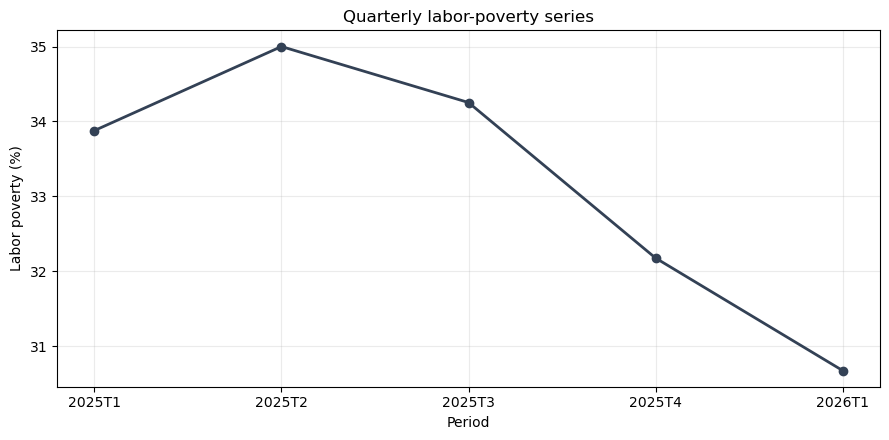

Saved output: outputs\indicators\labor_poverty_short_series_2025T1_2026T1.csv
Saved output: outputs\indicators\labor_poverty_short_series_2025T1_2026T1.parquet
Saved output: outputs\indicators\labor_poverty_short_series.png


In [11]:
series_result = run_library_call(
    UI["series"],
    compute_pl_time_series,
    analysis_sources=analysis_sources,
    periods=EXPECTED_PERIODS,
    lpei_quarterly=lpei_quarterly_wide,
    path_out=INDICATORS_DIR,
    output_name="labor_poverty_short_series_2025T1_2026T1",
    save_csv=True,
    save_parquet=True,
    overwrite=OVERWRITE_DERIVED,
    round_digits=INDICATOR_ROUND_DIGITS,
    stop_on_error=True,
    require_complete=False,
    generate_metadata=True,
    path_paradata=PARADATA_DIR,
    excluded_periods=DOCUMENTED_EXCLUDED_PERIODS,
)

series_data = series_result["data"].copy()
series_data["period"] = (
    series_data["Año"].astype(str)
    + "T"
    + series_data["Trimestre"].astype(str)
)
series_data = series_data[["period", "Año", "Trimestre", "PL"]]
display(localize_columns(series_data).style.format({"PL": "{:.2f}"}))

series_comparison = quarterly_indicator[["period", "pl_audit_pct"]].merge(
    series_data[["period", "PL"]],
    on="period",
    how="outer",
    validate="one_to_one",
)
series_comparison["absolute_difference"] = (
    series_comparison["pl_audit_pct"] - series_comparison["PL"]
).abs()
series_consistency_ok = bool(
    series_comparison["absolute_difference"].le(indicator_tolerance).all()
)

series_note = (
    UI["series_incomplete"].format(periods=missing_periods)
    if missing_periods
    else UI["series_complete"]
)
print(series_note)

figure, axis = plt.subplots(figsize=(9, 4.5))
axis.plot(series_data["period"], series_data["PL"], marker="o", linewidth=2, color="#334155")
axis.set_xlabel("Periodo" if LANGUAGE == "es" else "Period")
axis.set_ylabel("Pobreza laboral (%)" if LANGUAGE == "es" else "Labor poverty (%)")
axis.set_title(
    "Serie trimestral de pobreza laboral (incompleta)"
    if LANGUAGE == "es" and missing_periods
    else "Quarterly labor-poverty series (incomplete)"
    if LANGUAGE == "en" and missing_periods
    else "Serie trimestral de pobreza laboral"
    if LANGUAGE == "es"
    else "Quarterly labor-poverty series"
)
axis.grid(alpha=0.25)
figure.tight_layout()
chart_path = INDICATORS_DIR / "labor_poverty_short_series.png"
figure.savefig(chart_path, dpi=160, bbox_inches="tight")
plt.show()

for saved_path in [series_result["path_csv"], series_result["path_parquet"], chart_path]:
    print(UI["saved"].format(path=Path(saved_path).relative_to(BASE_DIR)))


To **verify the results** obtained using **official INEGI data**, please visit the following link: [Chek Official Labor Poverty](https://www.inegi.org.mx/desarrollosocial/pl/#informacion_general)

## 13. Concatenated history

`build_historical_analysis_parquet` concatenates validated analytical Parquet files into a person-quarter dataset. Unlike the aggregate series, it preserves individual analytical records for later analysis by period or characteristic. The function audits minimum columns, schema, period content, and `id_persona_periodo` uniqueness, and verifies that final rows equal the sum of the sources.

Inspection uses DuckDB and PyArrow without loading the entire history into memory. The automatic filename reflects the first and last period actually included, avoiding a false coverage claim.


In [13]:
historical_result = run_library_call(
    UI["historical"],
    build_historical_analysis_parquet,
    analysis_sources=analysis_sources,
    periods=EXPECTED_PERIODS,
    path_out=HISTORICAL_DIR,
    output_name="enoe_analisis_pl_2025T1_2026T1_en",
    overwrite=OVERWRITE_DERIVED,
    compression="zstd",
    row_group_size=100_000,
    strict_schema=True,
    validate_content=True,
    require_complete=False,
    stop_on_error=True,
    save_manifest=True,
    order_by_period=True,
    generate_metadata=True,
    path_paradata=PARADATA_DIR,
    excluded_periods=DOCUMENTED_EXCLUDED_PERIODS,
)

historical_path = Path(historical_result["path_output"])
historical_file = pq.ParquetFile(historical_path)
historical_columns = historical_file.schema.names
historical_path_sql = historical_path.resolve().as_posix().replace("'", "''")
with duckdb.connect(database=":memory:") as connection:
    historical_period_counts = connection.execute(f"""
        SELECT periodo, COUNT(*) AS rows
        FROM read_parquet('{historical_path_sql}')
        GROUP BY periodo
        ORDER BY periodo
    """).df()

included_historical_periods = historical_period_counts["periodo"].tolist()
unexpected_historical_periods = sorted(
    set(included_historical_periods) - set(processed_periods),
    key=period_sort_key,
)
missing_historical_periods = sorted(
    set(processed_periods) - set(included_historical_periods),
    key=period_sort_key,
)
critical_historical_columns = [
    "periodo", "id_persona_periodo", "id_hogar_periodo", "fac_tri",
    "ingreso_pc", "lpei", "entra_calculo_pl", "pobreza_laboral_persona",
]

historical_summary = pd.DataFrame([{
    "path": str(historical_path.relative_to(BASE_DIR)),
    "size_mb": historical_path.stat().st_size / 1024**2,
    "rows": historical_file.metadata.num_rows,
    "columns": len(historical_columns),
    "row_groups": historical_file.metadata.num_row_groups,
    "included_periods": included_historical_periods,
    "manifest": str(Path(historical_result["path_manifest"]).relative_to(BASE_DIR)),
    "critical_columns_present": all(column in historical_columns for column in critical_historical_columns),
}])
display(localize_columns(historical_summary))
display(localize_columns(historical_period_counts.rename(columns={"periodo": "period"})))


Stage completed: person-quarter history.


,Path,Size (MB),Rows,Columns,Row groups,Included periods,Manifest,Critical columns present
0,data\parquet\historical\enoe_analisis_pl_2025T...,122.033453,2051484,64,21,"[2025T1, 2025T2, 2025T3, 2025T4, 2026T1]",data\parquet\historical\enoe_analisis_pl_2025T...,True


,Period,Rows
0,2025T1,412079
1,2025T2,413004
2,2025T3,411562
3,2025T4,408099
4,2026T1,406740


## 14. JSON metadata inspection

Metadata describes the content, structure, size, construction, critical variables, and quality indicators of each file. The library stores it next to the corresponding Parquet. This section locates all JSON files, validates their syntax, summarizes their main keys, and shows a subset of relevant quality indicators without modifying any file.


In [14]:
metadata_search_roots = [
    CONVERTED_DIR,
    MERGED_DIR,
    ANALYTICAL_DIR,
    HISTORICAL_DIR,
    INDICATORS_DIR,
]
json_files = sorted({path for root in metadata_search_roots for path in root.rglob("*.json")})
json_inventory_records = []
json_documents = {}
json_parse_errors = []

for json_path in json_files:
    try:
        with json_path.open("r", encoding="utf-8") as stream:
            document = json.load(stream)
        json_documents[json_path] = document
        general = document.get("general_information", {})
        quality = document.get("quality_indicators", {})
        json_inventory_records.append({
            "file": str(json_path.relative_to(BASE_DIR)),
            "dataset_type": general.get("dataset_type", general.get("dataset_level", document.get("function"))),
            "period": general.get("dataset_period", general.get("period_range")),
            "main_keys": list(document.keys()),
            "quality_groups": list(quality.keys()) if isinstance(quality, dict) else [],
            "status": "válido" if LANGUAGE == "es" else "valid",
        })
    except Exception as error:
        json_parse_errors.append({"file": str(json_path), "error": f"{type(error).__name__}: {error}"})

json_inventory = pd.DataFrame(json_inventory_records)
if json_inventory.empty:
    print(UI["metadata_none"])
else:
    display(localize_columns(json_inventory.head(12)))

analysis_metadata_examples = [
    (path, document)
    for path, document in json_documents.items()
    if document.get("general_information", {}).get("dataset_type") == "analysis"
]
metadata_quality_rows = []
if analysis_metadata_examples:
    example_path, example_document = analysis_metadata_examples[0]
    for group_name, group_values in example_document.get("quality_indicators", {}).items():
        if isinstance(group_values, dict):
            for metric_name, metric_value in group_values.items():
                if not isinstance(metric_value, (dict, list)):
                    metadata_quality_rows.append({
                        "file": str(example_path.relative_to(BASE_DIR)),
                        "quality_group": group_name,
                        "metric": metric_name,
                        "value": metric_value,
                    })
metadata_quality_sample = pd.DataFrame(metadata_quality_rows)
if not metadata_quality_sample.empty:
    display(localize_columns(metadata_quality_sample.head(24)))


,File,Dataset type,Period,Main keys,Quality groups,Status
0,data\parquet\analytical\2025T1\ENOE_2025T1_ana...,analysis,2025T1,"[general_information, source_data, constructio...","[residence_quality, income_quality, imputation...",valid
1,data\parquet\analytical\2025T2\ENOE_2025T2_ana...,analysis,2025T2,"[general_information, source_data, constructio...","[residence_quality, income_quality, imputation...",valid
2,data\parquet\analytical\2025T3\ENOE_2025T3_ana...,analysis,2025T3,"[general_information, source_data, constructio...","[residence_quality, income_quality, imputation...",valid
3,data\parquet\analytical\2025T4\ENOE_2025T4_ana...,analysis,2025T4,"[general_information, source_data, constructio...","[residence_quality, income_quality, imputation...",valid
4,data\parquet\analytical\2026T1\ENOE_2026T1_ana...,analysis,2026T1,"[general_information, source_data, constructio...","[residence_quality, income_quality, imputation...",valid
5,data\parquet\converted\2025T1\COE2_metadata_qu...,raw_parquet,2025T1,"[general_information, source_data, constructio...","[conversion_quality, schema_quality, critical_...",valid
6,data\parquet\converted\2025T1\SDEM_metadata_qu...,raw_parquet,2025T1,"[general_information, source_data, constructio...","[conversion_quality, schema_quality, critical_...",valid
7,data\parquet\converted\2025T2\COE2_metadata_qu...,raw_parquet,2025T2,"[general_information, source_data, constructio...","[conversion_quality, schema_quality, critical_...",valid
8,data\parquet\converted\2025T2\SDEM_metadata_qu...,raw_parquet,2025T2,"[general_information, source_data, constructio...","[conversion_quality, schema_quality, critical_...",valid
9,data\parquet\converted\2025T3\COE2_metadata_qu...,raw_parquet,2025T3,"[general_information, source_data, constructio...","[conversion_quality, schema_quality, critical_...",valid


,File,Quality group,Metric,Value
0,data\parquet\analytical\2025T1\ENOE_2025T1_ana...,residence_quality,input_rows,4.233020e+05
1,data\parquet\analytical\2025T1\ENOE_2025T1_ana...,residence_quality,valid_residents,4.120790e+05
2,data\parquet\analytical\2025T1\ENOE_2025T1_ana...,residence_quality,discarded_by_residence,1.122300e+04
3,data\parquet\analytical\2025T1\ENOE_2025T1_ana...,residence_quality,valid_resident_rate_pct,9.734870e+01
4,data\parquet\analytical\2025T1\ENOE_2025T1_ana...,residence_quality,discarded_by_residence_rate_pct,2.651299e+00
5,data\parquet\analytical\2025T1\ENOE_2025T1_ana...,income_quality,occupied_persons,1.905030e+05
6,data\parquet\analytical\2025T1\ENOE_2025T1_ana...,income_quality,remunerated_occupied_persons,1.829200e+05
7,data\parquet\analytical\2025T1\ENOE_2025T1_ana...,income_quality,unpaid_workers,7.583000e+03
8,data\parquet\analytical\2025T1\ENOE_2025T1_ana...,income_quality,direct_p6b2_income_records,1.196970e+05
9,data\parquet\analytical\2025T1\ENOE_2025T1_ana...,income_quality,p6c_imputed_income_records,2.967900e+04


## 15. YAML paradata inspection

Paradata documents **how, when, and through which stages** data was processed: inputs, parameters, outputs, duration, warnings, errors, and overall status. Per-period YAML files accumulate conversion, merge, analytical construction, and indicator calculation; separate histories cover the aggregate series and historical dataset. Reading uses `yaml.safe_load`, validates every file, and displays limited summaries without changing them.

In `enoe-utilities 0.1.0`, `excluded_periods` is documentary paradata information and does not remove periods by itself. `2020T2` remains documented as a methodological exclusion even though it is outside this short example range.


In [15]:
yaml_files = sorted(PARADATA_DIR.rglob("*.yaml"))
yaml_documents = {}
yaml_inventory_records = []
yaml_parse_errors = []

for yaml_path in yaml_files:
    try:
        with yaml_path.open("r", encoding="utf-8") as stream:
            document = yaml.safe_load(stream)
        if not isinstance(document, dict):
            message = "La raíz YAML debe ser un mapeo" if LANGUAGE == "es" else "YAML root must be a mapping"
            raise TypeError(message)
        yaml_documents[yaml_path] = document
        steps = document.get("steps", []) or []
        warning_count = sum(len(step.get("warnings", []) or []) for step in steps if isinstance(step, dict))
        error_count = sum(len(step.get("errors", []) or []) for step in steps if isinstance(step, dict))
        yaml_inventory_records.append({
            "file": str(yaml_path.relative_to(BASE_DIR)),
            "period": document.get("periodo", document.get("periods", {}).get("processed")),
            "overall_status": document.get("status_general"),
            "steps": len(steps),
            "step_names": [step.get("step_name") for step in steps if isinstance(step, dict)],
            "warnings": warning_count,
            "errors": error_count,
        })
    except Exception as error:
        yaml_parse_errors.append({"file": str(yaml_path), "error": f"{type(error).__name__}: {error}"})

yaml_inventory = pd.DataFrame(yaml_inventory_records)
if yaml_inventory.empty:
    print(UI["paradata_none"])
else:
    display(localize_columns(yaml_inventory.head(12)))

period_yaml_examples = [
    (path, document)
    for path, document in yaml_documents.items()
    if document.get("paradata_type") == "period_processing_history"
]
paradata_step_rows = []
if period_yaml_examples:
    example_path, example_document = period_yaml_examples[0]
    for step in example_document.get("steps", []):
        paradata_step_rows.append({
            "file": str(example_path.relative_to(BASE_DIR)),
            "step_number": step.get("step_number"),
            "step_name": step.get("step_name"),
            "status": step.get("status"),
            "inputs": list((step.get("input") or {}).keys()) if isinstance(step.get("input"), dict) else None,
            "outputs": list((step.get("output") or {}).keys()) if isinstance(step.get("output"), dict) else None,
            "warnings": len(step.get("warnings", []) or []),
            "errors": len(step.get("errors", []) or []),
        })
paradata_step_sample = pd.DataFrame(paradata_step_rows)
if not paradata_step_sample.empty:
    display(localize_columns(paradata_step_sample))


,File,Period,Overall status,Steps,Stages,Warnings,Errors
0,outputs\paradata\2025T1\paradata_2025T1.yaml,2025T1,ok,17,"[conversion_zip_csv_to_parquet_coe2, conversio...",0,0
1,outputs\paradata\2025T2\paradata_2025T2.yaml,2025T2,ok,17,"[conversion_zip_csv_to_parquet_coe2, conversio...",0,0
2,outputs\paradata\2025T3\paradata_2025T3.yaml,2025T3,ok,17,"[conversion_zip_csv_to_parquet_coe2, conversio...",0,0
3,outputs\paradata\2025T4\paradata_2025T4.yaml,2025T4,ok,17,"[conversion_zip_csv_to_parquet_coe2, conversio...",0,0
4,outputs\paradata\2026T1\paradata_2026T1.yaml,2026T1,ok,17,"[conversion_zip_csv_to_parquet_coe2, conversio...",0,0
5,outputs\paradata\historico\paradata_historico_...,"[2025T1, 2025T2, 2025T3, 2025T4, 2026T1]",ok,4,"[normalize_sources, audit_input_parquets, conc...",0,0
6,outputs\paradata\serie_indicador\paradata_labo...,"[2025T1, 2025T2, 2025T3, 2025T4, 2026T1]",ok,3,"[normalize_analysis_sources, compute_pl_by_per...",0,0


,File,Step number,Stage,Status,Inputs,Outputs,Warnings,Errors
0,outputs\paradata\2025T1\paradata_2025T1.yaml,1,conversion_zip_csv_to_parquet_coe2,ok,"[object_name, object_type, path, role, contain...","[object_name, object_type, path, role]",0,0
1,outputs\paradata\2025T1\paradata_2025T1.yaml,2,conversion_zip_csv_to_parquet_sdem,ok,"[object_name, object_type, path, role, contain...","[object_name, object_type, path, role]",0,0
2,outputs\paradata\2025T1\paradata_2025T1.yaml,3,merge_sdem_coe2,ok,[objects],"[object_name, object_type, path, role, metadat...",0,0
3,outputs\paradata\2025T1\paradata_2025T1.yaml,4,merge_sdem_coe2,ok,[objects],"[object_name, object_type, path, role, metadat...",0,0
4,outputs\paradata\2025T1\paradata_2025T1.yaml,5,merge_sdem_coe2,ok,[objects],"[object_name, object_type, path, role, metadat...",0,0
5,outputs\paradata\2025T1\paradata_2025T1.yaml,6,build_analysis_dataset,ok,[objects],"[object_name, object_type, path, role]",0,0
6,outputs\paradata\2025T1\paradata_2025T1.yaml,7,compute_poverty_labor_period,ok,"[object_name, object_type, path]","[object_name, object_type, rows, columns]",0,0
7,outputs\paradata\2025T1\paradata_2025T1.yaml,8,conversion_zip_csv_to_parquet_coe2,reused,"[object_name, object_type, path, role, contain...","[object_name, object_type, path, role]",0,0
8,outputs\paradata\2025T1\paradata_2025T1.yaml,9,conversion_zip_csv_to_parquet_sdem,reused,"[object_name, object_type, path, role, contain...","[object_name, object_type, path, role]",0,0
9,outputs\paradata\2025T1\paradata_2025T1.yaml,10,merge_sdem_coe2,ok,[objects],"[object_name, object_type, path, role, metadat...",0,0


## 16. Final comparison and validation

The closing QA consolidates expected, found, processed, and missing periods; conversions; validations; LPEI coverage; merges; analytical datasets; indicators; history; JSON; and YAML. It also compares the direct quarterly calculation with the saved series. The status can only be `COMPLETE`, `COMPLETE WITH WARNINGS`, `INCOMPLETE`, or `FAILED`.

While `2025T1` is missing, the correct result is `INCOMPLETE`, even if all four available periods are processed without errors.


In [16]:
qa_errors = []
qa_warnings = list(RUNTIME_WARNINGS)

qa_text = {
    "es": {
        "invalid_schemas": "Esquemas inválidos: {value}",
        "invalid_merges": "Merges inválidos: {value}",
        "quarterly_difference": "La API trimestral y la auditoría agregada difieren más allá de la tolerancia.",
        "series_difference": "La auditoría trimestral y la serie guardada difieren más allá de la tolerancia.",
        "historical_mismatch": "Desajuste de periodos históricos. Inesperados={unexpected}; faltantes={missing}",
        "invalid_json": "Archivos JSON inválidos: {value}",
        "invalid_yaml": "Archivos YAML inválidos: {value}",
        "no_json": "No se generaron metadatos JSON.",
        "no_yaml": "No se generaron paradatos YAML.",
        "unexpected_inputs": "Archivos de entrada inesperados: {value}",
        "missing_expected": "Periodos esperados faltantes: {value}",
        "json_below": "Conteo JSON menor al mínimo esperado: {actual} < {expected}",
        "yaml_below": "Conteo YAML menor al mínimo esperado: {actual} < {expected}",
    },
    "en": {
        "invalid_schemas": "Invalid schemas: {value}",
        "invalid_merges": "Invalid merges: {value}",
        "quarterly_difference": "The quarterly API and aggregate audit differ beyond tolerance.",
        "series_difference": "The quarterly audit and saved time series differ beyond tolerance.",
        "historical_mismatch": "Historical period mismatch. Unexpected={unexpected}; missing={missing}",
        "invalid_json": "Invalid JSON files: {value}",
        "invalid_yaml": "Invalid YAML files: {value}",
        "no_json": "No JSON metadata were generated.",
        "no_yaml": "No YAML paradata were generated.",
        "unexpected_inputs": "Unexpected input files: {value}",
        "missing_expected": "Missing expected periods: {value}",
        "json_below": "JSON count below expected minimum: {actual} < {expected}",
        "yaml_below": "YAML count below expected minimum: {actual} < {expected}",
    },
}[LANGUAGE]

if invalid_schema_periods:
    qa_errors.append(qa_text["invalid_schemas"].format(value=invalid_schema_periods))
if invalid_merge_periods:
    qa_errors.append(qa_text["invalid_merges"].format(value=invalid_merge_periods))
if not indicator_consistency_ok:
    qa_errors.append(qa_text["quarterly_difference"])
if not series_consistency_ok:
    qa_errors.append(qa_text["series_difference"])
if unexpected_historical_periods or missing_historical_periods:
    qa_errors.append(qa_text["historical_mismatch"].format(
        unexpected=unexpected_historical_periods,
        missing=missing_historical_periods,
    ))
if json_parse_errors:
    qa_errors.append(qa_text["invalid_json"].format(value=json_parse_errors))
if yaml_parse_errors:
    qa_errors.append(qa_text["invalid_yaml"].format(value=yaml_parse_errors))
if not json_files:
    qa_errors.append(qa_text["no_json"])
if not yaml_files:
    qa_errors.append(qa_text["no_yaml"])
if unexpected_files:
    qa_warnings.append(qa_text["unexpected_inputs"].format(value=unexpected_files))
if missing_periods:
    qa_warnings.append(qa_text["missing_expected"].format(value=missing_periods))

expected_metadata_minimum = 4 * len(processed_periods) + 2
expected_paradata_minimum = len(processed_periods) + 2
if len(json_files) < expected_metadata_minimum:
    qa_warnings.append(qa_text["json_below"].format(actual=len(json_files), expected=expected_metadata_minimum))
if len(yaml_files) < expected_paradata_minimum:
    qa_warnings.append(qa_text["yaml_below"].format(actual=len(yaml_files), expected=expected_paradata_minimum))

all_target_parquets = sorted({
    path
    for root in [CONVERTED_DIR, MERGED_DIR, ANALYTICAL_DIR, HISTORICAL_DIR, INDICATORS_DIR]
    for path in root.rglob("*.parquet")
})
lpei_valid_periods = lpei_coverage.loc[lpei_coverage["lpei_ok"], "period"].tolist()

qa_metric_names = {
    "es": ["periodos esperados", "periodos encontrados", "periodos procesados", "periodos faltantes",
           "Parquet objetivo", "merges válidos", "datasets analíticos válidos", "indicadores calculados",
           "periodos LPEI con cobertura completa", "metadatos JSON", "paradatos YAML", "filas históricas",
           "errores", "advertencias"],
    "en": ["expected periods", "found periods", "processed periods", "missing periods", "target Parquet files",
           "valid merges", "valid analytical datasets", "calculated indicators", "LPEI periods with full coverage",
           "JSON metadata", "YAML paradata", "historical rows", "errors", "warnings"],
}[LANGUAGE]
qa_values = [
    (len(EXPECTED_PERIODS), EXPECTED_PERIODS), (len(found_periods), found_periods),
    (len(processed_periods), processed_periods), (len(missing_periods), missing_periods),
    (len(all_target_parquets), None), (int(merge_validation["ok"].sum()), None),
    (len(analysis_sources), list(analysis_sources)), (len(series_data), series_data["period"].tolist()),
    (len(lpei_valid_periods), lpei_valid_periods), (len(json_files), None), (len(yaml_files), None),
    (historical_result["filas_salida"], included_historical_periods), (len(qa_errors), qa_errors),
    (len(qa_warnings), qa_warnings),
]
qa_summary = pd.DataFrame([
    {"metric": metric_name, "value": metric_value, "details": details}
    for metric_name, (metric_value, details) in zip(qa_metric_names, qa_values)
])
display(localize_columns(qa_summary))

if qa_errors:
    FINAL_STATUS = "FAILED"
elif missing_periods:
    FINAL_STATUS = "INCOMPLETE"
elif qa_warnings:
    FINAL_STATUS = "COMPLETE WITH WARNINGS"
else:
    FINAL_STATUS = "COMPLETE"

print(UI["final_status"].format(status=FINAL_STATUS))
if "2025T1" in missing_periods:
    print(UI["add_file"].format(path="data/raw/zip/enoe_2025_trim1_csv.zip"))


,Metric,Value,Details
0,expected periods,5,"[2025T1, 2025T2, 2025T3, 2025T4, 2026T1]"
1,found periods,5,"[2025T1, 2025T2, 2025T3, 2025T4, 2026T1]"
2,processed periods,5,"[2025T1, 2025T2, 2025T3, 2025T4, 2026T1]"
3,missing periods,0,[]
4,target Parquet files,24,None
5,valid merges,5,None
6,valid analytical datasets,5,"[2025T1, 2025T2, 2025T3, 2025T4, 2026T1]"
7,calculated indicators,5,"[2025T1, 2025T2, 2025T3, 2025T4, 2026T1]"
8,LPEI periods with full coverage,5,"[2025T1, 2025T2, 2025T3, 2025T4, 2026T1]"
9,JSON metadata,23,None


FINAL STATUS: COMPLETE


## 17. Methodological and reproducibility limitations

- GitHub can display these notebooks but cannot execute them; results depend on local files and the local environment.
- This example neither redistributes nor replaces official sources. ENOE microdata and LPEI must be verified against INEGI and the applicable institutional documentation.
- File names and schemas may change. The included equivalences correspond to the verified `0.1.0` version.
- The series covers only five expected quarters and remains incomplete until the `2025T1` ZIP is available.
- `excluded_periods` is documentary in this version and does not automatically change calculations.
- Public validations remain notebook QA reports because they do not write paradata directly.
- The effect of imputation on PL is not estimated; it would require a defined and validated counterfactual scenario.
- The example does not automatically incorporate the complex survey design or compare every official historical result.
- This notebook is not an official publication. Before institutional use, review the data, current rules, QA artifacts, and results against official references.

**Conclusion:** the workflow is ready for “Restart Kernel and Run All.” If `2025T1` is still absent, add `data/raw/zip/enoe_2025_trim1_csv.zip`, restart the kernel, and run every cell to produce the complete series.
